In [2]:
# ==============================
# Handwritten Character Recognition
# Step 1 : Import Libraries
# ==============================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cv2
import os
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Conv2D,
    MaxPooling2D,
    Flatten,
    Dense,
    Dropout,
    BatchNormalization
)
from tensorflow.keras.datasets import mnist
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score
)
print("Libraries Imported Successfully")

Libraries Imported Successfully


In [3]:
# Load dataset
(X_train, y_train), (X_test, y_test) = mnist.load_data()

print("Training Images Shape :", X_train.shape)
print("Training Labels Shape :", y_train.shape)

print("Testing Images Shape :", X_test.shape)
print("Testing Labels Shape :", y_test.shape)

# Define the CNN model
model = Sequential([
    tf.keras.Input(shape=(28, 28, 1)), # Explicitly define input layer
    Conv2D(32, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Flatten(),
    Dense(128, activation='relu'),
    Dense(10, activation='softmax')
])

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Training Images Shape : (60000, 28, 28)
Training Labels Shape : (60000,)
Testing Images Shape : (10000, 28, 28)
Testing Labels Shape : (10000,)


In [4]:
print("\nImage Height :", X_train.shape[1])
print("Image Width :", X_train.shape[2])

print("\nNumber of Training Images :", len(X_train))
print("Number of Testing Images :", len(X_test))

print("\nUnique Classes :", np.unique(y_train))


Image Height : 28
Image Width : 28

Number of Training Images : 60000
Number of Testing Images : 10000

Unique Classes : [0 1 2 3 4 5 6 7 8 9]


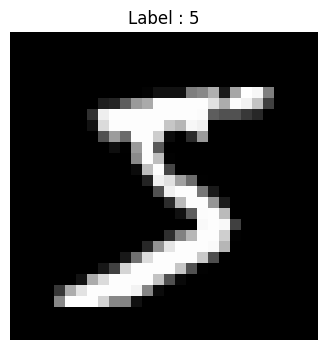

In [5]:
plt.figure(figsize=(4,4))
plt.imshow(X_train[0], cmap="gray")
plt.title(f"Label : {y_train[0]}")
plt.axis("off")
plt.show()

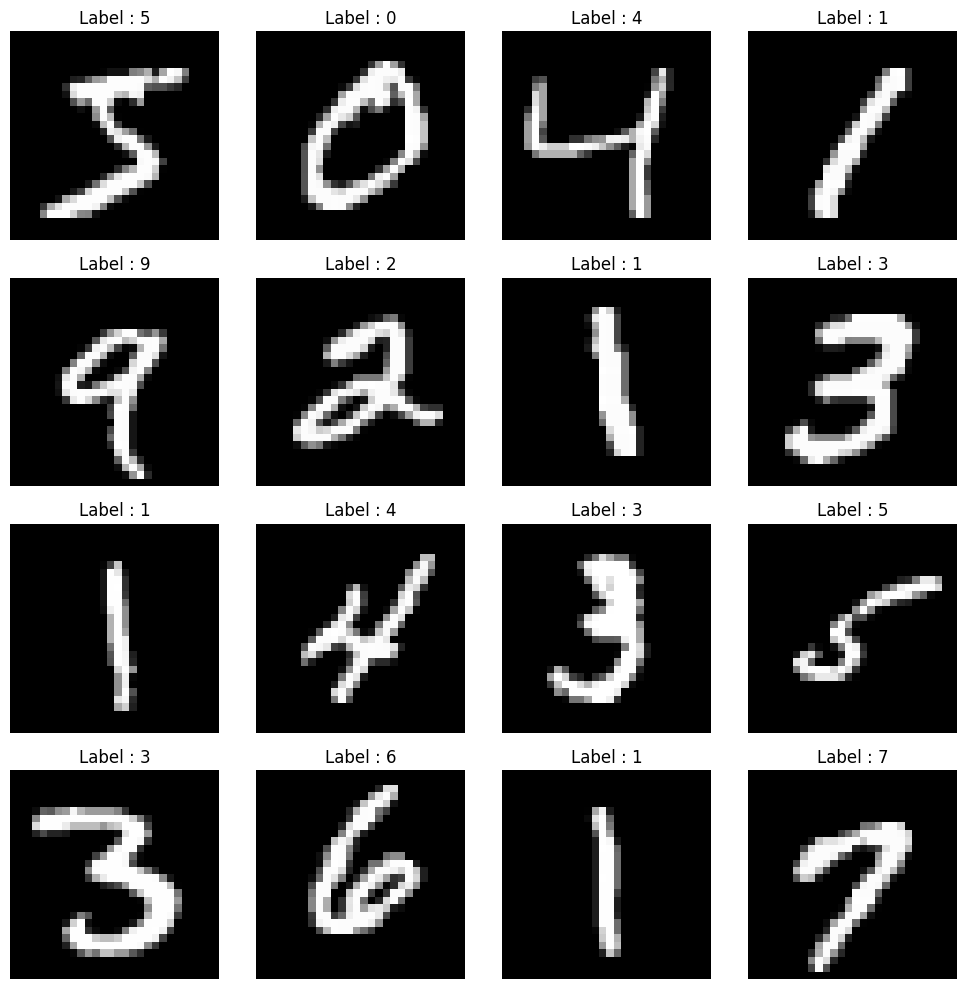

In [6]:
plt.figure(figsize=(10,10))
for i in range(16):
    plt.subplot(4,4,i+1)
    plt.imshow(X_train[i], cmap="gray")
    plt.title(f"Label : {y_train[i]}")
    plt.axis("off")
plt.tight_layout()
plt.show()

In [7]:
print("Image Data Type :", X_train.dtype)
print("Minimum Pixel Value :", X_train.min())
print("Maximum Pixel Value :", X_train.max())

Image Data Type : uint8
Minimum Pixel Value : 0
Maximum Pixel Value : 255


In [8]:
X_train = X_train.astype("float32") / 255.0
X_test = X_test.astype("float32") / 255.0

print("Minimum Pixel Value :", X_train.min())
print("Maximum Pixel Value :", X_train.max())

Minimum Pixel Value : 0.0
Maximum Pixel Value : 1.0


In [9]:
X_train = X_train.reshape(-1, 28, 28, 1)
X_test = X_test.reshape(-1, 28, 28, 1)

print("Training Shape :", X_train.shape)
print("Testing Shape :", X_test.shape)

Training Shape : (60000, 28, 28, 1)
Testing Shape : (10000, 28, 28, 1)


In [10]:

print("First 20 Labels:")
print(y_train[:20])

First 20 Labels:
[5 0 4 1 9 2 1 3 1 4 3 5 3 6 1 7 2 8 6 9]


In [11]:
print("Image Data Type :", X_train.dtype)
print("Label Data Type :", y_train.dtype)

Image Data Type : float32
Label Data Type : uint8


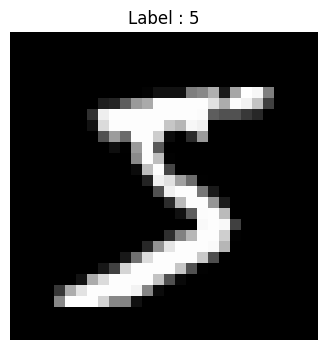

In [12]:
plt.figure(figsize=(4,4))
plt.imshow(X_train[0].reshape(28,28), cmap="gray")
plt.title(f"Label : {y_train[0]}")
plt.axis("off")
plt.show()

In [13]:
# Ensure X_train is 4D before fitting the ImageDataGenerator
if X_train.ndim == 3:
    X_train = X_train.reshape(-1, 28, 28, 1)

# Simplify ImageDataGenerator to diagnose high loss
datagen = ImageDataGenerator(
    # rotation_range=10,
    # zoom_range=0.10,
    # width_shift_range=0.10,
    # height_shift_range=0.10
)
datagen.fit(X_train)
print("Data Augmentation Ready")

Data Augmentation Ready


In [14]:
print("Training Images :", X_train.shape)
print("Training Labels :", y_train.shape)

print("Testing Images :", X_test.shape)
print("Testing Labels :", y_test.shape)

Training Images : (60000, 28, 28, 1)
Training Labels : (60000,)
Testing Images : (10000, 28, 28, 1)
Testing Labels : (10000,)


In [ ]:
# This cell is now empty as model.compile() has been moved to the model.fit() cell for robustness.

In [15]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

In [16]:
# Ensure X_train is 4D for datagen.flow
if X_train.ndim == 3:
    X_train = X_train.reshape(-1, 28, 28, 1)

# Ensure X_test is 4D for validation_data
if X_test.ndim == 3:
    X_test = X_test.reshape(-1, 28, 28, 1)

# Ensure model is compiled before fitting
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)
print("Model Compiled Successfully!")

history = model.fit(
    datagen.flow(X_train, y_train, batch_size=64),
    epochs=15,
    validation_data=(X_test, y_test),
    callbacks=[early_stop],
    verbose=1
)

Model Compiled Successfully!
Epoch 1/15
938/938 ━━━━━━━━━━━━━━━━━━━━ 56s 58ms/step - accuracy: 0.9536 - loss: 0.1533 - val_accuracy: 0.9821 - val_loss: 0.0585
Epoch 2/15
938/938 ━━━━━━━━━━━━━━━━━━━━ 75s 51ms/step - accuracy: 0.9857 - loss: 0.0466 - val_accuracy: 0.9872 - val_loss: 0.0360
Epoch 3/15
938/938 ━━━━━━━━━━━━━━━━━━━━ 48s 51ms/step - accuracy: 0.9898 - loss: 0.0325 - val_accuracy: 0.9905 - val_loss: 0.0288
Epoch 4/15
938/938 ━━━━━━━━━━━━━━━━━━━━ 49s 53ms/step - accuracy: 0.9927 - loss: 0.0228 - val_accuracy: 0.9902 - val_loss: 0.0318
Epoch 5/15
938/938 ━━━━━━━━━━━━━━━━━━━━ 47s 51ms/step - accuracy: 0.9944 - loss: 0.0179 - val_accuracy: 0.9911 - val_loss: 0.0262
Epoch 6/15
938/938 ━━━━━━━━━━━━━━━━━━━━ 48s 51ms/step - accuracy: 0.9952 - loss: 0.0140 - val_accuracy: 0.9884 - val_loss: 0.0397
Epoch 7/15
938/938 ━━━━━━━━━━━━━━━━━━━━ 50s 54ms/step - accuracy: 0.9965 - loss: 0.0116 - val_accuracy: 0.9907 - val_loss: 0.0297
Epoch 8/15
938/938 ━━━━━━━━━━━━━━━━━━━━ 49s 52ms/step - accur

In [17]:
print("Final Training Accuracy : {:.2f}%".format(
    history.history['accuracy'][-1] * 100
))

print("Final Validation Accuracy : {:.2f}%".format(
    history.history['val_accuracy'][-1] * 100
))

Final Training Accuracy : 99.71%
Final Validation Accuracy : 99.05%


In [21]:
from google.colab import files
model.save("handwritten_character_cnn.keras")

print("Model Saved Successfully!")
files.download("handwritten_character_cnn.keras")

Model Saved Successfully!


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [22]:
loss, accuracy = model.evaluate(X_test, y_test, verbose=1)

print(f"\nTest Loss     : {loss:.4f}")
print(f"Test Accuracy : {accuracy*100:.2f}%")

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.9911 - loss: 0.0262

Test Loss     : 0.0262
Test Accuracy : 99.11%


In [23]:
y_pred_prob = model.predict(X_test)

y_pred = y_pred_prob.argmax(axis=1)

print("First 10 Predictions:")
print(y_pred[:10])

print("\nActual Labels:")
print(y_test[:10])

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step
First 10 Predictions:
[7 2 1 0 4 1 4 9 5 9]

Actual Labels:
[7 2 1 0 4 1 4 9 5 9]


In [24]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.98      1.00      0.99       980
           1       0.99      1.00      1.00      1135
           2       0.99      0.99      0.99      1032
           3       0.99      0.99      0.99      1010
           4       1.00      0.99      0.99       982
           5       0.99      0.98      0.99       892
           6       0.99      0.99      0.99       958
           7       1.00      0.99      0.99      1028
           8       0.99      0.99      0.99       974
           9       0.99      0.99      0.99      1009

    accuracy                           0.99     10000
   macro avg       0.99      0.99      0.99     10000
weighted avg       0.99      0.99      0.99     10000



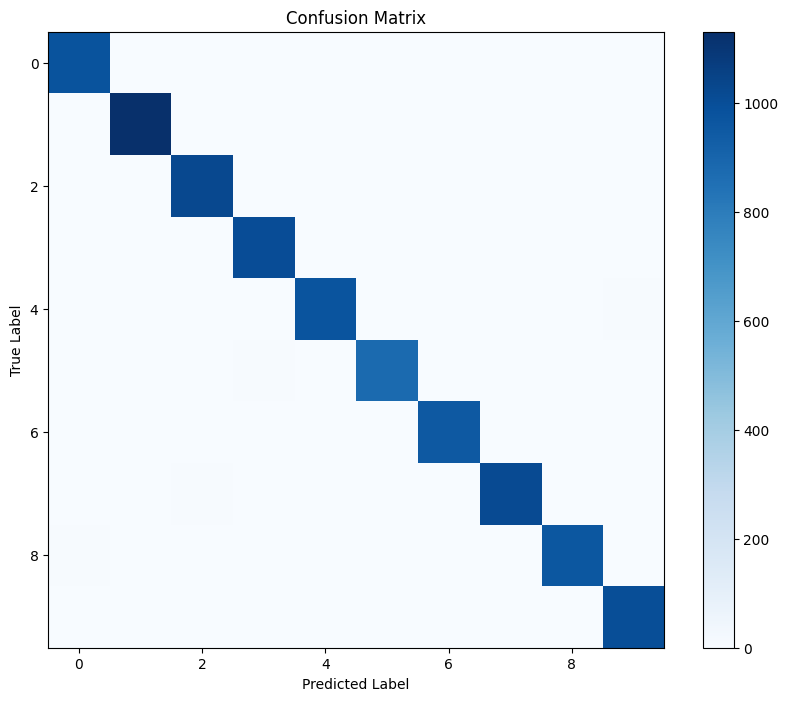

In [25]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(10,8))
plt.imshow(cm, cmap="Blues")
plt.colorbar()

plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.show()

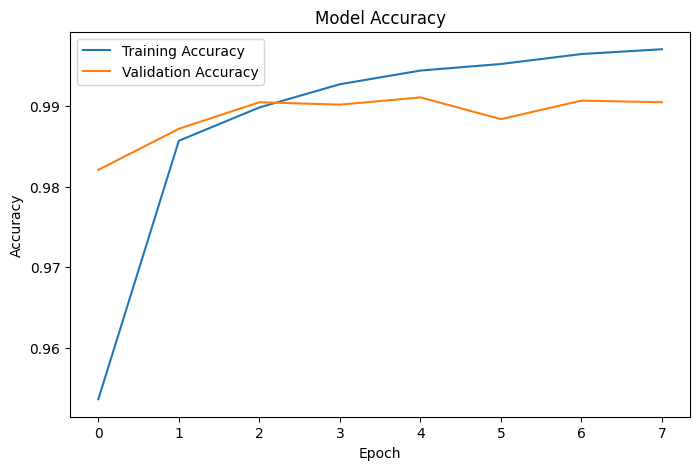

In [26]:
plt.figure(figsize=(8,5))

plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.title("Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.show()

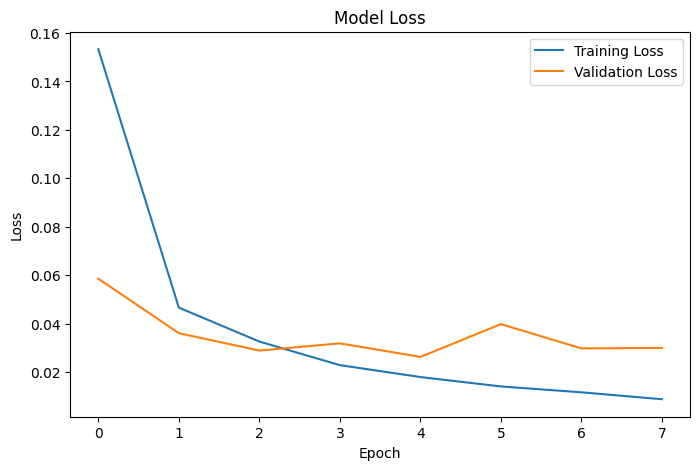

In [27]:
plt.figure(figsize=(8,5))

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.title("Model Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.show()

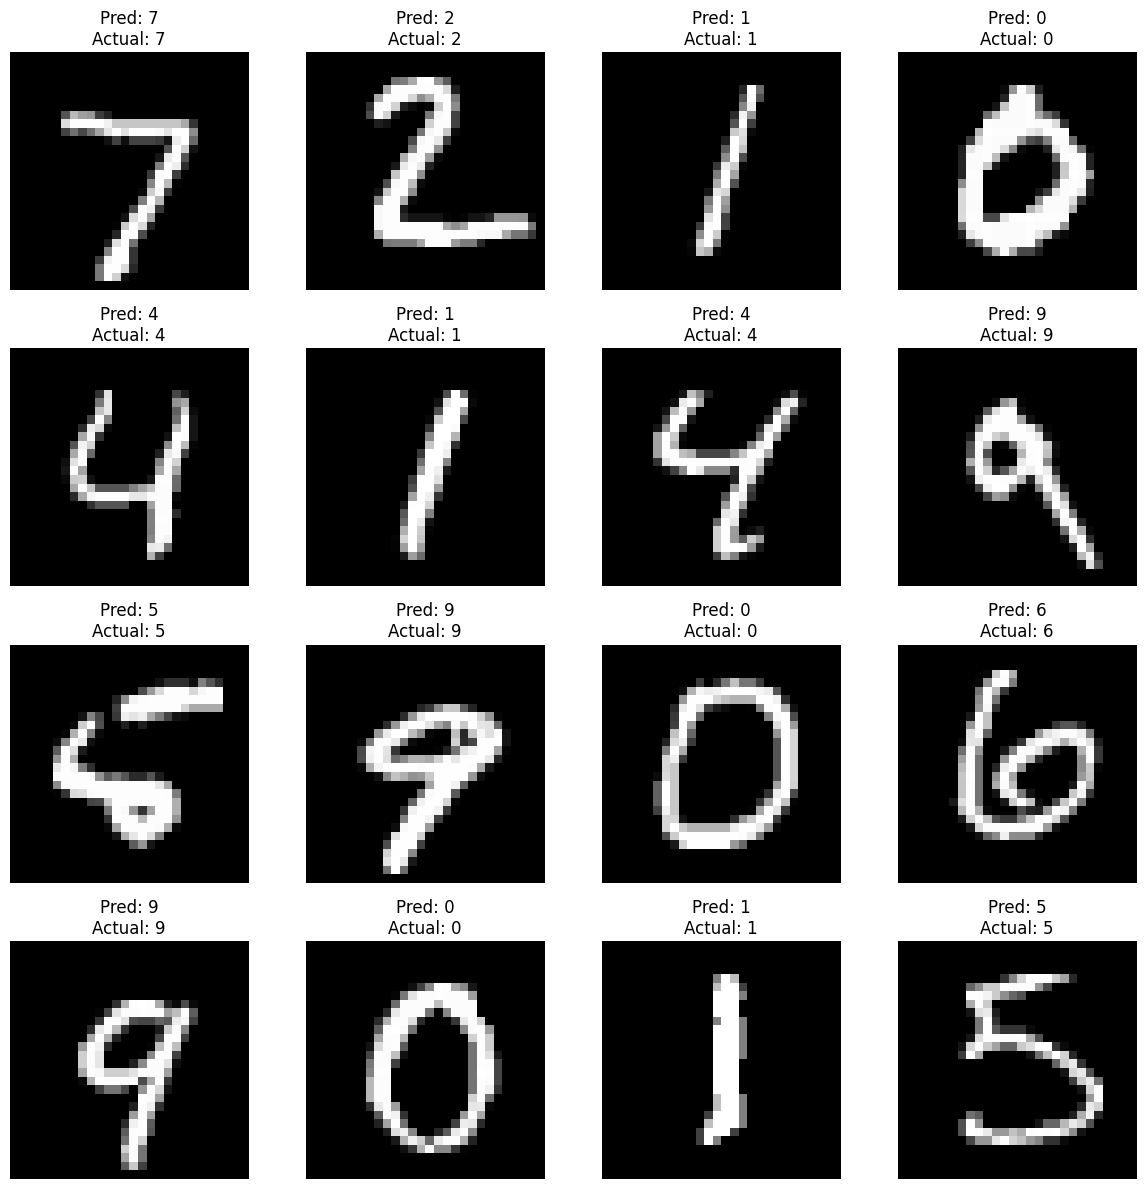

In [28]:
plt.figure(figsize=(12,12))
for i in range(16):
    plt.subplot(4,4,i+1)
    plt.imshow(X_test[i].reshape(28,28), cmap="gray")
    plt.title(f"Pred: {y_pred[i]}\nActual: {y_test[i]}")
    plt.axis("off")
plt.tight_layout()
plt.show()

In [29]:
from google.colab import files
model.save("handwritten_character_recognition.keras")
print("Model saved successfully!")
files.download("handwritten_character_recognition.keras")

Model saved successfully!


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>